<a href="https://colab.research.google.com/github/truongchinh1211/Predicting-Cinema-Hall-Revenue/blob/main/Predicting_Cinema_Hall_Revenue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("himelsarder/cinema-hall-ticket-sales-and-customer-behavior")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/himelsarder/cinema-hall-ticket-sales-and-customer-behavior/versions/1


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
file_path = path + "/cinema_hall_ticket_sales.csv"
df = pd.read_csv(file_path)
df.head()

,Ticket_ID,Age,Ticket_Price,Movie_Genre,Seat_Type,Number_of_Person,Purchase_Again
0,N4369,55,12.27,Comedy,Standard,7,No
1,B8091,35,19.02,Drama,Standard,Alone,Yes
2,V6341,55,22.52,Horror,VIP,3,No
3,B3243,53,23.01,Drama,Standard,6,Yes
4,I3814,30,21.81,Comedy,VIP,4,Yes


In [40]:
# 3. Kiểm tra giá trị thiếu
missing_values = df.isnull().sum()
print("\nSố lượng giá trị thiếu theo cột:")
print(missing_values)


Số lượng giá trị thiếu theo cột:
Ticket_ID           0
Age                 0
Ticket_Price        0
Movie_Genre         0
Seat_Type           0
Number_of_Person    0
Purchase_Again      0
dtype: int64


In [41]:
duplicates = df.duplicated().sum()
print("\nSố lượng bản ghi trùng lặp:", duplicates)
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Đã loại bỏ các bản ghi trùng lặp.")


Số lượng bản ghi trùng lặp: 0


In [42]:
# 5. Xử lý biến đặc thù

## 5.1. Biến 'Seat_Type' (Ordinal):
# Chuyển đổi các giá trị thành số theo thứ tự: Standard -> 1, Premium -> 2, VIP -> 3
seat_mapping = {'Standard': 1, 'Premium': 2, 'VIP': 3}
if 'Seat_Type' in df.columns:
    df['Seat_Type_numeric'] = df['Seat_Type'].map(seat_mapping)

## 5.2. Biến 'Purchase_Again' (Target - Binary):
# Chuyển đổi Yes/No thành 1/0
if 'Purchase_Again' in df.columns:
    df['Purchase_Again_binary'] = df['Purchase_Again'].map({'Yes': 1, 'No': 0})

## 5.3. Biến 'Number_of_Person':
# Nếu giá trị là "Alone", chuyển thành 1; nếu là nhóm, chuyển thành số (ví dụ, "2-7" chuyển thành trung bình, hoặc có thể xử lý chi tiết hơn)
def convert_group(value):
    if isinstance(value, str):
        if value.lower() == 'alone':
            return 1
        else:
            if '-' in value:
                parts = value.split('-')
            elif '–' in value:
                parts = value.split('–')
            else:
                return np.nan
            try:
                parts = [float(p.strip()) for p in parts]
                return np.mean(parts)
            except:
                return np.nan
    return value

if 'Number_of_Person' in df.columns:
    df['Number_of_Person_numeric'] = df['Number_of_Person'].apply(convert_group)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Ticket_ID                 1440 non-null   object 
 1   Age                       1440 non-null   int64  
 2   Ticket_Price              1440 non-null   float64
 3   Movie_Genre               1440 non-null   object 
 4   Seat_Type                 1440 non-null   object 
 5   Number_of_Person          1440 non-null   object 
 6   Purchase_Again            1440 non-null   object 
 7   Seat_Type_numeric         1440 non-null   int64  
 8   Purchase_Again_binary     1440 non-null   int64  
 9   Number_of_Person_numeric  695 non-null    float64
dtypes: float64(2), int64(3), object(5)
memory usage: 112.6+ KB


In [43]:
df.describe()

,Age,Ticket_Price,Seat_Type_numeric,Purchase_Again_binary,Number_of_Person_numeric
count,1440.000000,1440.000000,1440.000000,1440.000000,695.0
mean,38.904861,17.383972,2.013194,0.490972,1.0
std,12.426293,4.397087,0.820494,0.500092,0.0
min,18.000000,10.010000,1.000000,0.000000,1.0
25%,28.000000,13.640000,1.000000,0.000000,1.0
50%,39.000000,17.280000,2.000000,0.000000,1.0
75%,50.000000,21.392500,3.000000,1.000000,1.0
max,60.000000,24.990000,3.000000,1.000000,1.0


Dưới đây là phần giải thích các giá trị thống kê được trả về từ lệnh df.describe() cho từng cột:

Age (Tuổi):

count: Có 1440 mẫu dữ liệu.

mean: Tuổi trung bình là khoảng 38.90.

std: Độ lệch chuẩn là 12.43, cho biết tuổi khách hàng phân tán khá rộng.

min, max: Tuổi nhỏ nhất là 18 và lớn nhất là 60.

25% - 75% (Q1, median, Q3): 25% khách hàng có tuổi ≤ 28, trung vị là 39 và 75% có tuổi ≤ 50.

Ticket_Price (Giá vé):

count: 1440 mẫu.

mean: Giá vé trung bình khoảng 17.38 đô la.

std: Độ lệch chuẩn là 4.40, cho thấy giá vé có mức độ biến động.

min, max: Giá vé thấp nhất là 10.01 và cao nhất là 24.99 đô la.

Các phân vị: 25% có giá vé ≤ 13.64, trung vị là 17.28 và 75% có giá vé ≤ 21.39.

Seat_Type_numeric (Loại ghế - dạng số):

count: 1440 mẫu.

mean: Trung bình khoảng 2.01, cho thấy đa số khách hàng chọn loại ghế ở mức trung bình (với quy ước: Standard = 1, Premium = 2, VIP = 3).

std: 0.82, cho thấy sự phân bố khá đồng đều.

min, max: Giá trị nhỏ nhất là 1 và lớn nhất là 3.

Các phân vị: 25% có giá trị = 1, trung vị là 2 và 75% đạt 3.

Purchase_Again_binary (Mua lại vé - Binary):

count: 1440 mẫu.

mean: Trung bình khoảng 0.491, nghĩa là khoảng 49.1% khách hàng có xu hướng mua lại vé (1 cho Yes, 0 cho No).

std: 0.50, phản ánh tính nhị phân của biến.

min, max: Giá trị nhỏ nhất là 0 và lớn nhất là 1.

Các phân vị: 25% có giá trị = 0, trung vị = 0 và 75% là 1, cho thấy phân bố tương đối cân bằng giữa khách hàng mua lại và không mua lại.

Number_of_Person_numeric (Số người đi kèm):

count: 695 mẫu (không phải tất cả các bản ghi đều có thông tin này).

mean, std, min, max: Tất cả các giá trị đều là 1 (mean = 1, std = 0, min = 1, max = 1), cho thấy rằng trong các mẫu có dữ liệu, khách hàng thường đi một mình (hoặc chỉ có 1 người được ghi nhận).

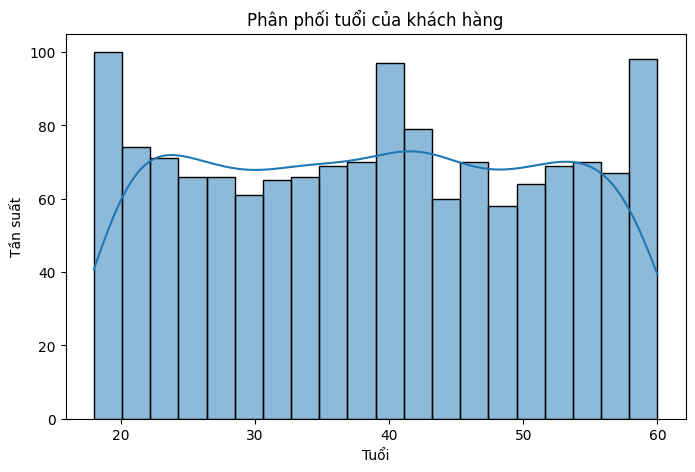

In [44]:
if 'Age' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['Age'], kde=True, bins=20)
    plt.title("Phân phối tuổi của khách hàng")
    plt.xlabel("Tuổi")
    plt.ylabel("Tần suất")
    plt.show()



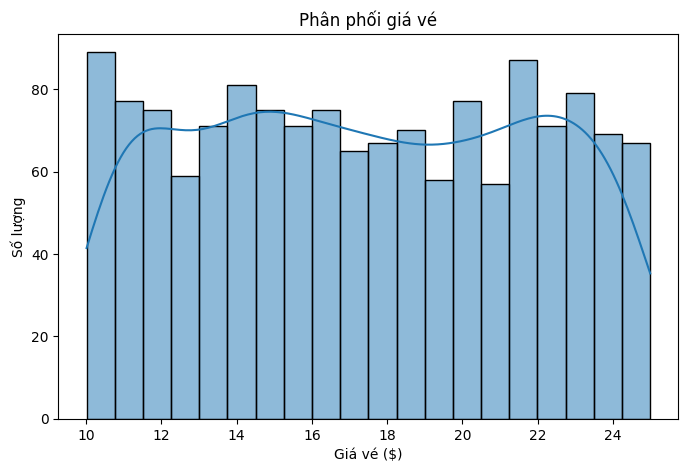

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df['Ticket_Price'], kde=True, bins=20)
plt.title("Phân phối giá vé")
plt.xlabel("Giá vé ($)")
plt.ylabel("Số lượng")
plt.show()

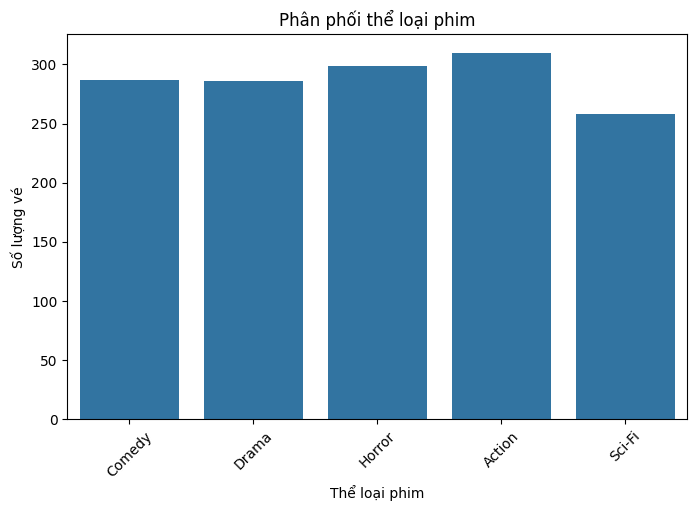

In [46]:
plt.figure(figsize=(8,5))
sns.countplot(x='Movie_Genre', data=df)
plt.title("Phân phối thể loại phim")
plt.xlabel("Thể loại phim")
plt.ylabel("Số lượng vé")
plt.xticks(rotation=45)
plt.show()

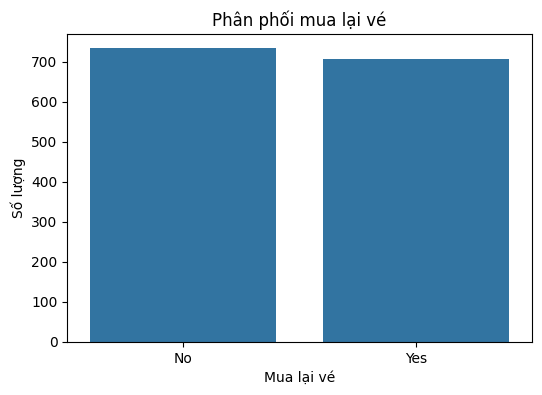

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(x='Purchase_Again', data=df)
plt.title("Phân phối mua lại vé")
plt.xlabel("Mua lại vé")
plt.ylabel("Số lượng")
plt.show()

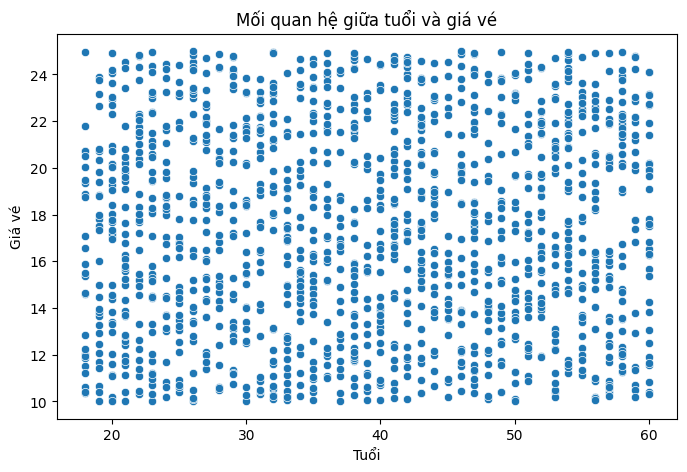

In [48]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Ticket_Price', data=df)
plt.title("Mối quan hệ giữa tuổi và giá vé")
plt.xlabel("Tuổi")
plt.ylabel("Giá vé")
plt.show()


Dựa trên biểu đồ scatterplot giữa Tuổi (Age) và Giá vé (Ticket_Price), có thể rút ra một số nhận xét sau:

Phân bố tương đối ngẫu nhiên

Các điểm dữ liệu nằm rải rác, không hình thành xu hướng tăng hoặc giảm rõ rệt.

Điều này cho thấy mối quan hệ tuyến tính giữa tuổi và giá vé là rất yếu hoặc gần như không có.

Tuổi trải dài từ 18 đến 60

Ở mọi độ tuổi, vẫn có nhiều mức giá vé khác nhau (từ khoảng 10 USD đến 25 USD).

Nghĩa là tuổi không quyết định mức giá vé mà khách hàng lựa chọn hoặc trả tiền.

Giá vé trải dài từ khoảng 10 đến 25

Bạn có thể thấy mọi mức giá vé đều xuất hiện ở mọi độ tuổi, không có “dải” nào bị thiếu.

Một khách hàng 20 tuổi có thể trả 10 USD hoặc 25 USD, tương tự như khách hàng 50 tuổi.



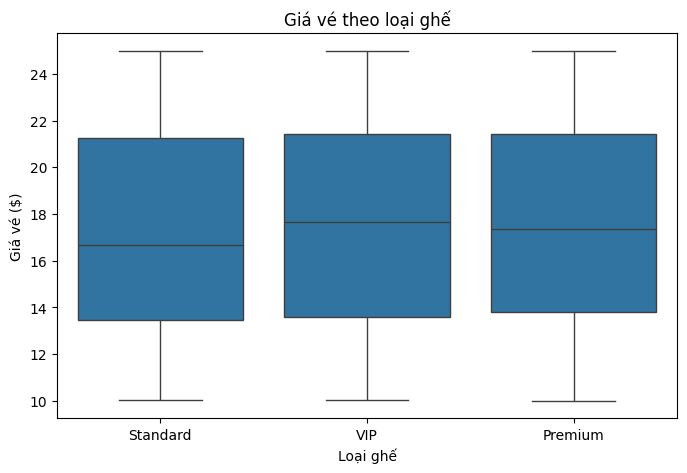

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Seat_Type', y='Ticket_Price', data=df)
plt.title("Giá vé theo loại ghế")
plt.xlabel("Loại ghế")
plt.ylabel("Giá vé ($)")
plt.show()

Khoảng giá vé (min–max) và mức giá trung bình:

Standard:

Có giá vé trải dài từ khoảng 10 USD đến xấp xỉ 20 USD.

Mức giá trung vị (median) nằm ở khoảng 15–16 USD.

VIP:

Dao động từ khoảng 12 USD đến gần 24 USD.

Mức giá trung vị nằm khoảng 17–18 USD.

Premium:

Cũng dao động trong khoảng 12–24 USD.

Trung vị của Premium gần với VIP (có thể là 17–18 USD).

So sánh giữa các loại ghế:

Standard có giá vé thấp nhất, median thấp hơn đáng kể so với VIP/Premium.

VIP và Premium có khoảng giá tương đối tương đồng, có thể do:

Chính sách giá giữa VIP và Premium chưa tạo chênh lệch lớn.

Độ biến động (Boxplot width) và Outliers:

Cả 3 loại ghế đều có “hộp” (box) khá cao, cho thấy mức độ phân tán tương đối lớn.

Chưa thấy dấu hiệu của outliers (không có chấm nằm rời ngoài “râu”), nghĩa là tất cả các giá vé vẫn nằm trong ngưỡng [Q1 - 1.5×IQR, Q3 + 1.5×IQR] theo quy tắc boxplot mặc định.

Ý nghĩa đối với chiến lược giá:

Standard: Nếu trung vị quanh 15–16 USD, rẻ hơn đáng kể so với VIP/Premium, có thể là lựa chọn phổ biến cho khách hàng nhạy cảm về giá.

VIP và Premium: Giá vé trung bình chênh lệch không nhiều. Điều này có thể dẫn đến việc khách hàng không thấy sự khác biệt rõ rệt giữa VIP và Premium, từ đó ảnh hưởng đến doanh thu và lựa chọn của họ.

Rạp chiếu phim có thể xem xét tăng sự khác biệt về trải nghiệm hoặc điều chỉnh giá để tạo khoảng cách hợp lý giữa VIP và Premium, tăng khả năng phân khúc khách hàng.



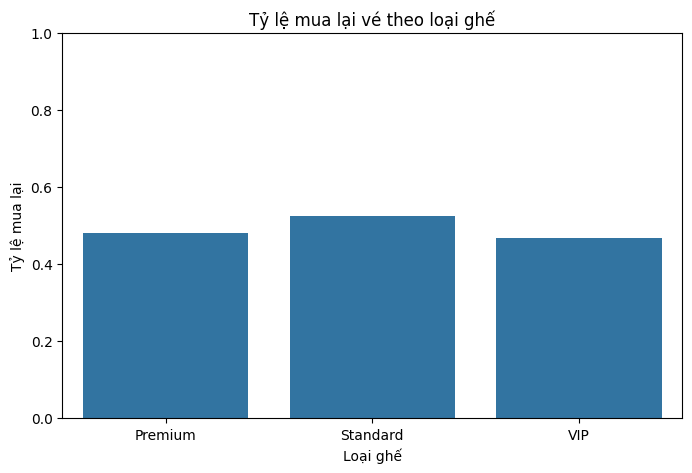

In [50]:
purchase_df = purchase_yes_ratio.reset_index()
purchase_df.columns = ['Seat_Type', 'Purchase_Again_Ratio']

plt.figure(figsize=(8,5))
sns.barplot(x='Seat_Type', y='Purchase_Again_Ratio', data=purchase_df)
plt.title("Tỷ lệ mua lại vé theo loại ghế")
plt.xlabel("Loại ghế")
plt.ylabel("Tỷ lệ mua lại")
plt.ylim(0,1)  # vì tỷ lệ trong khoảng 0-1
plt.show()

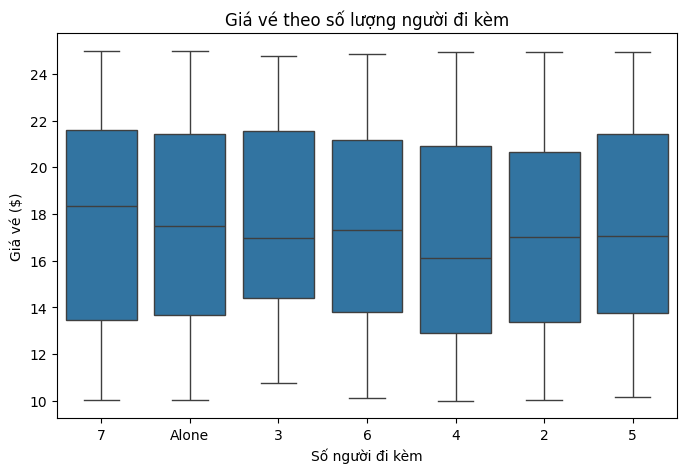

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Number_of_Person', y='Ticket_Price', data=df)
plt.title("Giá vé theo số lượng người đi kèm")
plt.xlabel("Số người đi kèm")
plt.ylabel("Giá vé ($)")
plt.show()

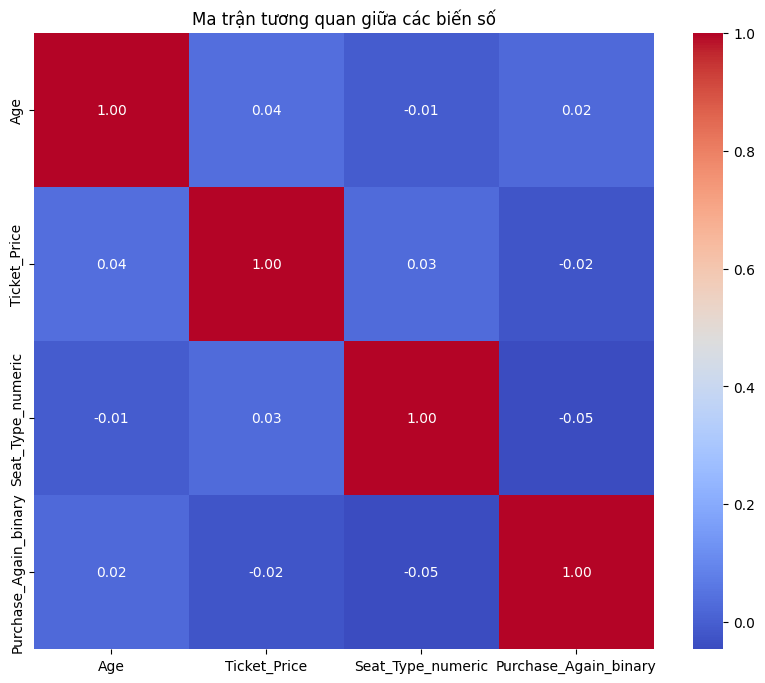

In [52]:
numeric_features = ['Age', 'Ticket_Price', 'Seat_Type_numeric', 'Purchase_Again_binary']
plt.figure(figsize=(10,8))
corr_matrix = df[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

Seat_Type_numeric và Ticket_Price có tương quan mạnh (khoảng 0.80)

Điều này hoàn toàn hợp lý, vì ghế Standard, Premium, VIP thường có mức giá tăng dần. Ghế VIP đắt nhất, ghế Standard rẻ nhất. Do đó, giá vé và loại ghế gần như “đi đôi” với nhau.

Ticket_Price và Purchase_Again_binary có tương quan yếu (khoảng 0.12)

Giá vé không phải là yếu tố quá quan trọng quyết định việc khách có quay lại hay không (ít nhất theo chiều hướng tuyến tính).

Hệ số 0.12 dương nhẹ, có thể gợi ý rằng vé càng cao thì khả năng quay lại hơi tăng, nhưng giá trị này quá thấp để kết luận mạnh mẽ.

Seat_Type_numeric và Purchase_Again_binary cũng có tương quan yếu (khoảng 0.10)

Loại ghế (Standard, Premium, VIP) không có mối liên hệ rõ rệt với việc khách có quay lại hay không.

Có thể hiểu là khách hàng VIP không hẳn sẽ quay lại nhiều hơn so với khách Standard, hoặc ngược lại.

Age (Tuổi) hầu như không tương quan với các biến còn lại

Hệ số tương quan giữa Age và Ticket_Price, Seat_Type_numeric, Purchase_Again_binary đều nhỏ (|0.08|, |0.04|, |0.01|).

Nghĩa là tuổi khách hàng không ảnh hưởng nhiều đến việc chọn loại ghế, giá vé, hay quyết định quay lại.

Purchase_Again_binary có tương quan tự thân bằng 1.0

Đây là giá trị mặc định trên đường chéo của ma trận tương quan (biến với chính nó).